# OLG: Competitive Equilibrium vs Planner's Problem

This notebook solves the **same** two-period OLG economy two ways and compares the results:

1. **Decentralised competitive equilibrium** — households save, firms hire, markets clear. Dynamics reduce to a **first-order scalar recursion** $k_{t+1} = g(k_t)$, solved by simple forward iteration.
2. **Planner's problem** (command optimum) — a benevolent social planner chooses the full intergenerational allocation, discounting future generations at rate $R$. Dynamics are a **first-order 2D system** in $(k_t, c^1_t)$ with saddle-path structure. We solve it by **eigenvector projection** onto the stable manifold — linearised but analytically clean, and it makes the economic content of the TVC transparent.

**Economy:** Cobb–Douglas production $f(k)=k^\alpha$, log utility, planner discount $R\ge 0$ between generations.

**Calibration:** $\alpha=0.36$, $\beta=0.40\approx 0.97^{30}$, $n=0.10$. Period length: 30 years. $R$ is a free parameter — change it and re-run to see how the planner's allocation responds.

## 1. Setup and parameters

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Structural parameters ---
alpha = 0.36      # capital share in Cobb-Douglas production
beta  = 0.40      # generational discount factor (~ 0.97^30 annual)
n     = 0.10      # generational population growth
R     = 1.8         # planner's intergenerational discount rate  <-- change me

# --- Composite constants used throughout the planner block ---
rho_fac = (1 + n) * (1 + R)    # (1+n)(1+R): appears in Euler denominator & MGR
chi     = 1 + beta * (1 + R)   # aggregator in the planner resource constraint

# Course palette (matches Beamer slides)
NAVY, ACCENT, MUTED, GREEN = '#1E2761', '#C0392B', '#5A6172', '#27AE60'

print(f'Planner discount: R = {R:.3f}   →   (1+n)(1+R) = {rho_fac:.4f},   χ = 1+β(1+R) = {chi:.4f}')

Planner discount: R = 1.800   →   (1+n)(1+R) = 3.0800,   χ = 1+β(1+R) = 2.1200


## 2. Decentralised Competitive Equilibrium

### 2.1 The transition map

Under Cobb–Douglas + log utility, the household's saving function is independent of the interest rate (income and substitution effects cancel):
$$s_t = \frac{\beta}{1+\beta}\, w_t.$$

Firms pay the competitive wage $w_t = (1-\alpha) k_t^\alpha$. Capital market clearing $(1+n)k_{t+1} = s_t$ gives the **scalar first-order recursion**:
$$k_{t+1} = \underbrace{\frac{\beta(1-\alpha)}{(1+\beta)(1+n)}}_{\equiv\,A}\, k_t^\alpha \equiv g(k_t).$$

Notice: **no forward-looking agent, no TVC, no jump variable, no $R$**. The competitive equilibrium is completely independent of the planner's discount rate — $R$ is a purely normative object, used only when we ask what allocation a social planner would choose. The household's 2-period horizon doesn't see it.

In [5]:
# --- Transition map for the decentralised economy (R does not appear) ---
def g_dec(k):
    # Decentralised OLG transition: k_{t+1} = A * k^alpha, with A = beta(1-alpha)/[(1+beta)(1+n)].
    A = (beta / (1 + beta)) * (1 - alpha) / (1 + n)
    return A * k ** alpha

# --- Decentralised steady state: solve k = A*k^alpha ---
A_dec  = (beta * (1 - alpha)) / ((1 + beta) * (1 + n))
k_ss_dec = A_dec ** (1 / (1 - alpha))

# Steady-state factor prices (note: r is the generational rate, not annual)
r_ss_dec = alpha * k_ss_dec ** (alpha - 1)       # gross MPK
w_ss_dec = (1 - alpha) * k_ss_dec ** alpha       # wage per worker

print(f'Decentralised steady state (independent of R)')
print(f'  k*   = {k_ss_dec:.4f}')
print(f'  r*   = {r_ss_dec:.4f}   (generational; annual ~ {(1+r_ss_dec)**(1/30)-1:.2%})')
print(f'  n    = {n:.4f}   (generational; annual ~ {(1+n)**(1/30)-1:.2%})')
print(f'  r* > n: dynamically efficient')

Decentralised steady state (independent of R)
  k*   = 0.0606
  r*   = 2.1656   (generational; annual ~ 3.92%)
  n    = 0.1000   (generational; annual ~ 0.32%)
  r* > n: dynamically efficient


### 2.2 Forward iteration

One line of logic: start at $k_0$, apply $g$ repeatedly. Convergence rate (linearised): $g'(k^*) = \alpha = 0.36$ per generation — the **capital share controls the speed**. Gap to steady state shrinks by 64% each generation.

In [8]:
# --- Simulate transition from k_0 = k_ss/3 (arbitrary) ---
T_sim = 20
k0_dec = k_ss_dec / 3.0

k_path_dec = np.empty(T_sim + 1)
k_path_dec[0] = k0_dec
for t in range(T_sim):
    k_path_dec[t + 1] = g_dec(k_path_dec[t])

# Recover consumption allocations along the path:
#   c^1_t = (1 / (1+beta)) * w_t       (consumption when young)
#   c^2_{t+1} = (1 + r_{t+1}) * s_t     (consumption when old, next period)
w_path = (1 - alpha) * k_path_dec ** alpha
r_path = alpha * k_path_dec ** (alpha - 1)
c1_path_dec = w_path / (1 + beta)
s_path = (beta / (1 + beta)) * w_path
c2_path_dec = (1 + r_path[1:]) * s_path[:-1]   # c^2 of cohort born at t, consumed at t+1

print(f'k_0 = {k_path_dec[0]:.4f}')
print(f'k_{T_sim} = {k_path_dec[-1]:.4f}  (target k* = {k_ss_dec:.4f})')
print(f'gap closed: {100*(1 - abs(k_path_dec[-1] - k_ss_dec)/abs(k_path_dec[0] - k_ss_dec)):.2f}%')

k_0 = 0.0202
k_20 = 0.0606  (target k* = 0.0606)
gap closed: 100.00%


## 3. Planner's Problem

### 3.1 The first-order system (with planner discount $R$)

The planner maximises
$$V = \sum_{t=0}^\infty \Big(\tfrac{1}{1+R}\Big)^t \Big[\log c^1_t + \beta \log c^2_{t+1}\Big]$$
subject to the per-young resource constraint $c^1_t + c^2_t/(1+n) + (1+n)k_{t+1} = k_t + k_t^\alpha$.

The planner's intratemporal FOC (comparing $c^1_t$ and $c^2_t$ across generations living at date $t$) gives
$$\frac{c^2_t}{c^1_t} \;=\; \beta(1+n)(1+R).$$
Substituting into the resource constraint produces a reduced 2D system in $(k_t, c^1_t)$:
$$
\begin{aligned}
k_{t+1} &= \frac{k_t + k_t^\alpha - \chi\, c^1_t}{1+n}, \qquad \chi \equiv 1+\beta(1+R),\\[2pt]
c^1_{t+1} &= c^1_t \cdot \frac{1 + \alpha\, k_{t+1}^{\alpha-1}}{(1+n)(1+R)}.
\end{aligned}
$$
$c^1_t$ is a **jump variable** — the planner chooses it freely at $t=0$, subject to the TVC.

### 3.2 Steady state (modified golden rule)

At stationarity the Euler collapses to
$$1 + f'(k^*) = (1+n)(1+R) \;\;\Longrightarrow\;\; k^* = \Big(\frac{\alpha}{(1+n)(1+R)-1}\Big)^{1/(1-\alpha)}.$$
Setting $R=0$ recovers the golden rule $f'(k^*)=n$. Raising $R$ makes the planner more impatient and pushes $k^*$ toward the decentralised steady state.

In [11]:
# --- Planner's steady state: modified golden rule ---
# 1 + f'(k*) = (1+n)(1+R) = rho_fac
k_ss_pla  = (alpha / (rho_fac - 1)) ** (1 / (1 - alpha))
c1_ss_pla = (k_ss_pla ** alpha - n * k_ss_pla) / chi
c2_ss_pla = beta * rho_fac * c1_ss_pla    # c^2/c^1 = β(1+n)(1+R) at SS

print(f"Planner steady state  (R = {R:.3f})")
print(f"  k*      = {k_ss_pla:.4f}   (vs decentralised {k_ss_dec:.4f},  ratio {k_ss_pla/k_ss_dec:.2f}×)")
print(f"  c^1*    = {c1_ss_pla:.4f}")
print(f"  c^2*    = {c2_ss_pla:.4f}")
print(f"  f'(k*)  = {alpha*k_ss_pla**(alpha-1):.4f}   (should equal (1+n)(1+R)-1 = {rho_fac-1:.4f})")

Planner steady state  (R = 1.800)
  k*      = 0.0645   (vs decentralised 0.0606,  ratio 1.07×)
  c^1*    = 0.1728
  c^2*    = 0.2129
  f'(k*)  = 2.0800   (should equal (1+n)(1+R)-1 = 2.0800)


Observe how the planner's $k^*$ responds to $R$:

| $R$ | $k^*_\text{planner}$ | ratio vs CE |
|---:|---:|---:|
| 0.00 | 7.40 | 122× |
| 0.25 | 0.94 | 16× |
| 0.50 | 0.40 | 6.6× |
| 0.99 | 0.15 | 2.6× |

At $R=0$ the planner weights all cohorts equally and accumulates enormous capital. As $R$ rises she discounts future generations more heavily, and the optimal $k^*$ collapses toward (but never reaches) the decentralised level. **The decentralised $k^*$ is R-invariant by construction** — households don't see $R$ at all.

### 3.3 Saddle-path via eigenvector projection

**Linearise the 2D system around $(k^*, c^{1*})$.** Defining $\kappa \equiv c^{1*} f''(k^*)/(1+n)$ (negative) and $\gamma \equiv \chi/(1+n)$ (positive), the Jacobian is
$$
J \;=\; \begin{pmatrix} 1+R & -\gamma \\ \kappa & 1-\dfrac{\kappa\gamma}{1+R}\end{pmatrix}
\qquad \det J = 1+R.
$$
Setting $R=0$ recovers the familiar $\det J = 1$ case (eigenvalues are reciprocals, $\mu_s\mu_u=1$). For $R>0$ the eigenvalues satisfy $\mu_s\mu_u = 1+R$ — still a saddle, but the stable and unstable roots are no longer reciprocals.

**The TVC selects the stable manifold.** Any initial condition off the stable eigenvector places weight on $\mu_u > 1$, so the state explodes. The TVC forbids that, so the planner's optimal $c^1_0$ places the economy on the stable eigenvector $v_s$:
$$(k_0 - k^*,\; c^1_0 - c^{1*}) \;=\; \tfrac{k_0-k^*}{v_{s,1}}\,v_s.$$

**Along the saddle path the dynamics contract at rate $\mu_s$ per generation**, so the full transition is
$$(k_t - k^*,\; c^1_t - c^{1*}) \;=\; \mu_s^t\,(k_0 - k^*,\; c^1_0 - c^{1*}).$$
This is a closed form — no numerical iteration needed, and the saddle-path structure is completely transparent.

In [15]:
# --- Build the Jacobian at the steady state ---
f_dd = alpha * (alpha - 1) * k_ss_pla ** (alpha - 2)   # f''(k*)
kappa = c1_ss_pla * f_dd / (1 + n)                     # < 0
gam   = chi / (1 + n)                                   # > 0

J = np.array([
    [1.0 + R,     -gam                 ],
    [kappa,       1 - kappa * gam / (1 + R)]
])

print('Jacobian at (k*, c^1*):')
print(J)
print(f'\ntrace = {np.trace(J):.4f}')
print(f'det   = {np.linalg.det(J):.4f}   (should equal 1+R = {1+R:.4f})')

Jacobian at (k*, c^1*):
[[ 2.8        -1.92727273]
 [-3.24110539  3.23089073]]

trace = 6.0309
det   = 2.8000   (should equal 1+R = 2.8000)


In [17]:
# --- Find the stable eigenvalue and its eigenvector ---
eigvals, eigvecs = np.linalg.eig(J)
i_stable = np.argmin(np.abs(eigvals))                  # smallest-modulus eigenvalue
mu_s = eigvals[i_stable].real
mu_u = eigvals[1 - i_stable].real
v_s  = eigvecs[:, i_stable].real

# The stable eigenvector spans the saddle-path policy rule:
#   c^1 - c^1* = slope * (k - k*)
slope = v_s[1] / v_s[0]

print(f'Stable eigenvalue   mu_s = {mu_s:.4f}   (persistence; gap closes ~{100*(1-mu_s):.0f}% per gen.)')
print(f'Unstable eigenvalue mu_u = {mu_u:.4f}')
print(f'mu_s * mu_u        = {mu_s*mu_u:.4f}   (= 1+R = {1+R:.4f})')
print(f'Saddle-path slope dc^1/dk = {slope:.4f}')
print()
print('Comparison of convergence speeds:')
print(f'  Decentralised:  {alpha:.2f} per gen. (gap closes {100*(1-alpha):.0f}%)')
print(f'  Planner:        {mu_s:.2f} per gen. (gap closes {100*(1-mu_s):.0f}%)')
print('The more impatient the planner (higher R), the faster she converges.')

Stable eigenvalue   mu_s = 0.5069   (persistence; gap closes ~49% per gen.)
Unstable eigenvalue mu_u = 5.5240
mu_s * mu_u        = 2.8000   (= 1+R = 2.8000)
Saddle-path slope dc^1/dk = 1.1898

Comparison of convergence speeds:
  Decentralised:  0.36 per gen. (gap closes 64%)
  Planner:        0.51 per gen. (gap closes 49%)
The more impatient the planner (higher R), the faster she converges.


In [19]:
# --- Project the initial condition onto the stable manifold ---
k0_pla = 0.7 * k_ss_pla
c1_0_pla = c1_ss_pla + slope * (k0_pla - k_ss_pla)

print(f'Initial capital   k_0   = {k0_pla:.4f}  (= 0.7 · k*)')
print(f'Saddle-path c^1_0       = {c1_0_pla:.4f}  (linearised)')
print(f'Steady-state c^1*       = {c1_ss_pla:.4f}')

Initial capital   k_0   = 0.0452  (= 0.7 · k*)
Saddle-path c^1_0       = 0.1498  (linearised)
Steady-state c^1*       = 0.1728


In [21]:
# --- Iterate the LINEARISED dynamics along the stable manifold ---
# Along v_s the system contracts by the factor mu_s each generation:
#    (k_t - k*, c^1_t - c^1*) = mu_s^t * (k_0 - k*, c^1_0 - c^1*)
# This is the saddle-path method in its pure form. Iterating the nonlinear
# map from the linearised IC would amplify O(eps^2) projection error by mu_u^t,
# which is tolerable at R=0 but explodes for R>0 (mu_u grows with R).

T_pla = 30
t_grid = np.arange(T_pla + 1)
k_path_pla  = k_ss_pla  + (mu_s ** t_grid) * (k0_pla   - k_ss_pla)
c1_path_pla = c1_ss_pla + (mu_s ** t_grid) * (c1_0_pla - c1_ss_pla)

print(f'Saddle-path dynamics (linearised around steady state):')
print(f'  k_0  = {k_path_pla[0]:.4f}   c^1_0 = {c1_path_pla[0]:.4f}')
print(f'  k_{T_pla:2d} = {k_path_pla[-1]:.4f}   (target k* = {k_ss_pla:.4f})')
print(f'  gap  = {abs(k_path_pla[-1] - k_ss_pla):.2e}   (closes as mu_s^{T_pla} = {mu_s**T_pla:.2e})')

Saddle-path dynamics (linearised around steady state):
  k_0  = 0.0452   c^1_0 = 0.1498
  k_30 = 0.0645   (target k* = 0.0645)
  gap  = 2.72e-11   (closes as mu_s^30 = 1.40e-09)


### 3.4 Phase diagram in $(k, c^1)$ space

We now visualise the saddle-point structure directly. In the linearised system around $(k^*, c^{1*})$ the two nullclines are

$$\Delta k = 0:\quad c^1 - c^{1*} = \tfrac{R}{\gamma}\,(k - k^*), \qquad \Delta c^1 = 0:\quad c^1 - c^{1*} = \tfrac{1+R}{\gamma}\,(k - k^*),$$

where $\gamma = \chi/(1+n)$. The two eigenvectors of $J$ — stable (slope $\mu_s$-eigenvector) and unstable (slope $\mu_u$-eigenvector) — sit between these nullclines and define the saddle-path geometry. Only the green stable arm leads to the steady state; any other initial choice of $c^1_0$ is amplified by $\mu_u$ each generation and diverges.

Nullcline slopes (linearised):
  Δk  = 0:  slope = R/γ      = 0.9340
  Δc¹ = 0:  slope = (1+R)/γ  = 1.4528
Eigenvector slopes:
  stable arm    (saddle path):  slope = 1.1898
  unstable arm:                  slope = -1.4134


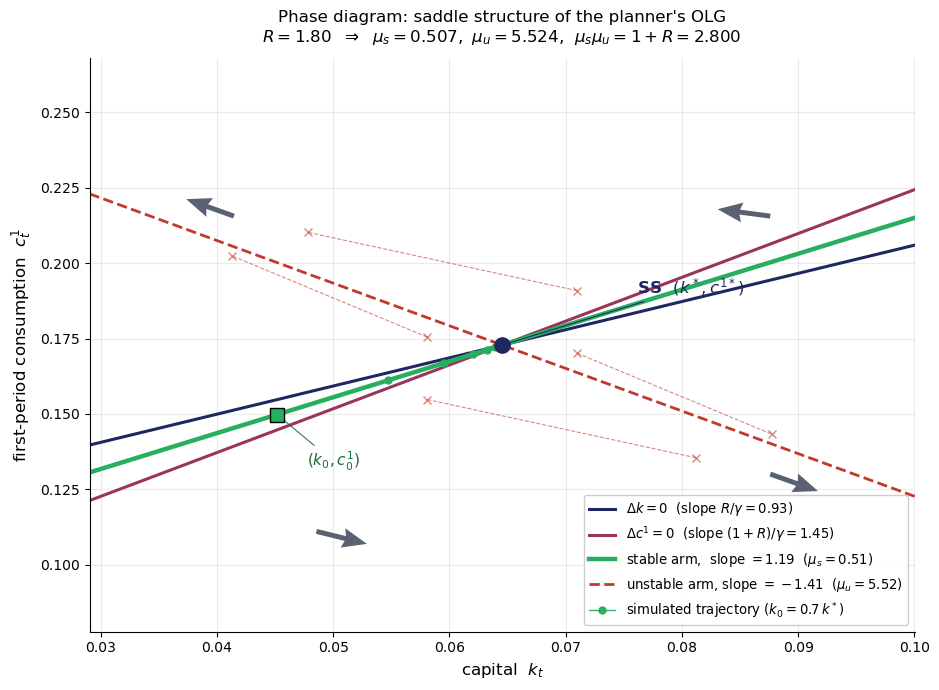

In [24]:
# --- Phase diagram in (k, c^1) space around the planner's steady state ---
# Uses J, mu_s, mu_u, v_s, slope, k_ss_pla, c1_ss_pla and the trajectory
# (k_path_pla, c1_path_pla) computed in cells above.

# Unstable eigenvector and its slope
v_u     = eigvecs[:, 1 - i_stable].real
slope_u = v_u[1] / v_u[0]

# Linearised nullcline slopes
slope_dk = R / gam              # Δk = 0:   slope = R/γ
slope_dc = (1 + R) / gam        # Δc¹ = 0:  slope = (1+R)/γ

print('Nullcline slopes (linearised):')
print(f'  Δk  = 0:  slope = R/γ      = {slope_dk:.4f}')
print(f'  Δc¹ = 0:  slope = (1+R)/γ  = {slope_dc:.4f}')
print('Eigenvector slopes:')
print(f'  stable arm    (saddle path):  slope = {slope:.4f}')
print(f'  unstable arm:                  slope = {slope_u:.4f}')

# ----- plot -----
fig, ax = plt.subplots(figsize=(9.5, 7))

half_k = 0.55 * k_ss_pla
half_c = 0.55 * c1_ss_pla
kmin, kmax = k_ss_pla - half_k, k_ss_pla + half_k
cmin, cmax = c1_ss_pla - half_c, c1_ss_pla + half_c
ax.set_xlim(kmin, kmax)
ax.set_ylim(cmin, cmax)

# nullclines
xx = np.linspace(kmin, kmax, 200)
ax.plot(xx, c1_ss_pla + slope_dk * (xx - k_ss_pla),
        color=NAVY, lw=2.2,
        label=fr'$\Delta k = 0$  (slope $R/\gamma = {slope_dk:.2f}$)')
ax.plot(xx, c1_ss_pla + slope_dc * (xx - k_ss_pla),
        color='#993556', lw=2.2,
        label=fr'$\Delta c^1 = 0$  (slope $(1+R)/\gamma = {slope_dc:.2f}$)')

# stable arm (saddle path)
ax.plot(xx, c1_ss_pla + slope * (xx - k_ss_pla),
        color=GREEN, lw=3.2,
        label=fr'stable arm,  slope $= {slope:.2f}$  ($\mu_s={mu_s:.2f}$)')
# unstable arm
ax.plot(xx, c1_ss_pla + slope_u * (xx - k_ss_pla),
        color=ACCENT, lw=2.0, ls='--',
        label=fr'unstable arm, slope $= {slope_u:.2f}$  ($\mu_u={mu_u:.2f}$)')

# Vector-field arrows: qualitative direction at points off the steady state.
# We compute the actual one-step linearised motion (Δk, Δc¹) = (J - I) x
# at a small grid of points and use ax.quiver for proper vector-field rendering.
J_minus_I = J - np.eye(2)
qx, qy, qu, qv = [], [], [], []
sample_pts = [
    ( half_k * 0.65,  half_c * 0.45),   # NE of SS
    (-half_k * 0.65,  half_c * 0.45),   # NW
    (-half_k * 0.45, -half_c * 0.65),   # SW (below IC)
    ( half_k * 0.65, -half_c * 0.45),   # SE
]
for (dx, dy) in sample_pts:
    motion = J_minus_I @ np.array([dx, dy])
    nrm = np.hypot(motion[0] / k_ss_pla, motion[1] / c1_ss_pla)
    if nrm == 0:
        continue
    qx.append(k_ss_pla + dx)
    qy.append(c1_ss_pla + dy)
    qu.append(motion[0] / nrm)   # direction only (unit-ish in scaled units)
    qv.append(motion[1] / nrm)

ax.quiver(qx, qy, qu, qv,
          angles='xy', scale_units='xy', scale=14,
          width=0.006, headwidth=4, headlength=5,
          color=MUTED, zorder=4)

# Saddle-path trajectory we actually simulated
ax.plot(k_path_pla, c1_path_pla, 'o-', color=GREEN, ms=5, lw=1.0,
        alpha=0.95, label='simulated trajectory ($k_0 = 0.7\\, k^*$)')

# Divergent trajectories: kick a tiny bit OFF the stable arm and iterate J
for x0 in [-0.10 * k_ss_pla, +0.10 * k_ss_pla]:
    for kick in [+0.06 * c1_ss_pla, -0.06 * c1_ss_pla]:
        state = np.array([x0, slope * x0 + kick])
        traj = [state.copy()]
        for _ in range(8):
            state = J @ state
            if (abs(state[0]) > 0.6 * k_ss_pla or
                abs(state[1]) > 0.6 * c1_ss_pla):
                break
            traj.append(state.copy())
        traj = np.array(traj)
        ax.plot(traj[:, 0] + k_ss_pla, traj[:, 1] + c1_ss_pla,
                'x--', color=ACCENT, ms=6, lw=0.8, alpha=0.6)

# Steady state marker
ax.plot(k_ss_pla, c1_ss_pla, 'o', color=NAVY, ms=11, zorder=5)
ax.annotate(r'SS  $(k^*, c^{1*})$',
            xy=(k_ss_pla, c1_ss_pla),
            xytext=(k_ss_pla + 0.18 * k_ss_pla,
                    c1_ss_pla + 0.10 * c1_ss_pla),
            fontsize=12, color=NAVY, fontweight='bold',
            arrowprops=dict(arrowstyle='-', color=NAVY, lw=0.7))

# Initial condition marker (placed clear of trajectory line)
ax.plot(k_path_pla[0], c1_path_pla[0], 's', color=GREEN, ms=10,
        markeredgecolor='black', zorder=6)
ax.annotate(r'$(k_0, c^1_0)$',
            xy=(k_path_pla[0], c1_path_pla[0]),
            xytext=(k_path_pla[0] + 0.04 * k_ss_pla,
                    c1_path_pla[0] - 0.10 * c1_ss_pla),
            fontsize=11, color='#1A6B3A', fontweight='bold',
            arrowprops=dict(arrowstyle='-', color='#1A6B3A', lw=0.7))

ax.set_xlabel(r'capital  $k_t$', fontsize=12)
ax.set_ylabel(r'first-period consumption  $c^1_t$', fontsize=12)
ax.set_title(
    "Phase diagram: saddle structure of the planner's OLG\n"
    fr"$R={R:.2f}$  $\Rightarrow$  $\mu_s={mu_s:.3f},\ \mu_u={mu_u:.3f}$,  "
    fr"$\mu_s\mu_u = 1+R = {1+R:.3f}$",
    fontsize=12, pad=12)
ax.grid(True, alpha=0.25)
ax.legend(loc='lower right', fontsize=9.5, framealpha=0.95)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


## 4. Visual comparison

Plot both economies side-by-side. Because the steady-state capital stocks differ by (at least) an order of magnitude, we plot them on **separate panels** — each path normalised to its own steady state.

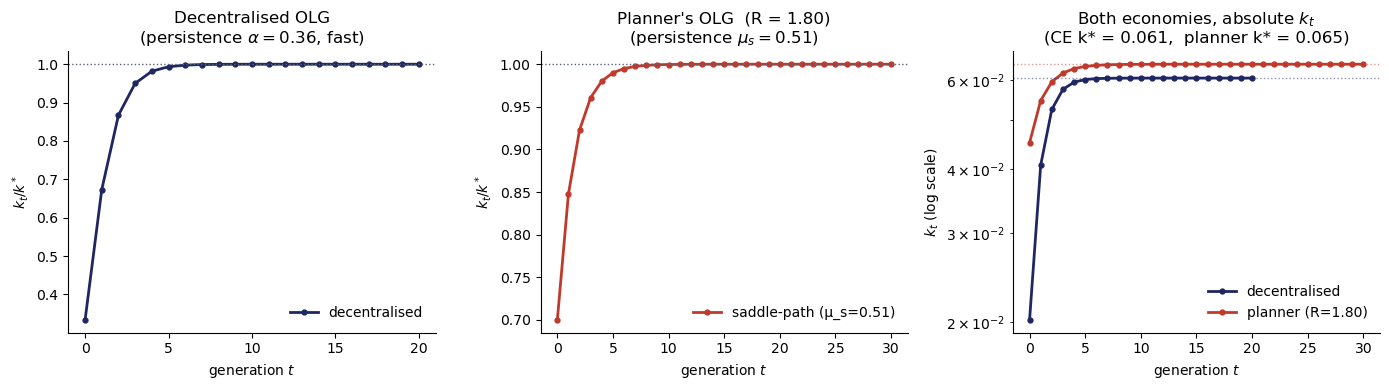

In [27]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))

# --- Panel 1: decentralised path (own scale) ---
ax[0].plot(range(T_sim+1), k_path_dec/k_ss_dec, color=NAVY, lw=2, marker='o', ms=3.5,
           label='decentralised')
ax[0].axhline(1.0, color=MUTED, ls=':', lw=1)
ax[0].set_xlabel('generation $t$')
ax[0].set_ylabel(r'$k_t/k^*$')
ax[0].set_title(f'Decentralised OLG\n(persistence $\\alpha={alpha}$, fast)')
ax[0].legend(frameon=False, loc='lower right')

# --- Panel 2: planner saddle-path (own scale) ---
ax[1].plot(range(T_pla+1), k_path_pla/k_ss_pla, color=ACCENT, lw=2, marker='o', ms=3.5,
           label=f'saddle-path (μ_s={mu_s:.2f})')
ax[1].axhline(1.0, color=MUTED, ls=':', lw=1)
ax[1].set_xlabel('generation $t$')
ax[1].set_ylabel(r'$k_t/k^*$')
ax[1].set_title(f"Planner's OLG  (R = {R:.2f})\n(persistence $\\mu_s={mu_s:.2f}$)")
ax[1].legend(frameon=False, loc='lower right')

# --- Panel 3: both overlaid (absolute k, log scale) ---
ax[2].semilogy(range(T_sim+1), k_path_dec, color=NAVY, lw=2, marker='o', ms=3.5,
               label='decentralised')
ax[2].semilogy(range(T_pla+1), k_path_pla, color=ACCENT, lw=2, marker='o', ms=3.5,
               label=f'planner (R={R:.2f})')
ax[2].axhline(k_ss_dec, color=NAVY,   ls=':', lw=1, alpha=0.5)
ax[2].axhline(k_ss_pla, color=ACCENT, ls=':', lw=1, alpha=0.5)
ax[2].set_xlabel('generation $t$')
ax[2].set_ylabel(r'$k_t$ (log scale)')
ax[2].set_title(f'Both economies, absolute $k_t$\n(CE k* = {k_ss_dec:.3f},  planner k* = {k_ss_pla:.3f})')
ax[2].legend(frameon=False, loc='lower right')

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

### 4.1 Comparative statics in $R$

To see how the planner's allocation responds to her own discount rate, sweep $R$ and plot the resulting $k^*$ and $\mu_s$.

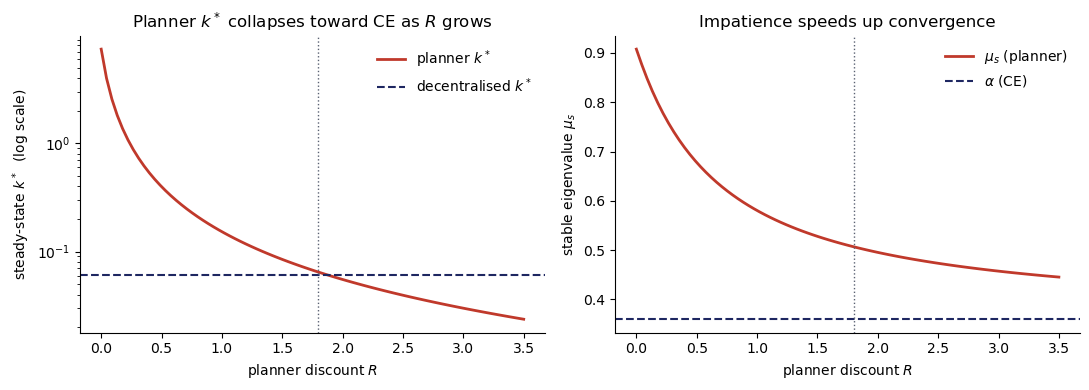

In [30]:
# --- Sweep R and recompute the planner steady state and stable eigenvalue ---
R_grid = np.linspace(0.0, 3.5, 80)
k_ss_grid = np.empty_like(R_grid)
mu_s_grid = np.empty_like(R_grid)

for i, Ri in enumerate(R_grid):
    rho_i = (1 + n) * (1 + Ri)
    chi_i = 1 + beta * (1 + Ri)
    k_i   = (alpha / (rho_i - 1)) ** (1 / (1 - alpha))
    c1_i  = (k_i**alpha - n*k_i) / chi_i
    fdd_i = alpha*(alpha-1)*k_i**(alpha-2)
    kap_i = c1_i * fdd_i / (1 + n)
    gam_i = chi_i / (1 + n)
    J_i   = np.array([[1+Ri, -gam_i],[kap_i, 1 - kap_i*gam_i/(1+Ri)]])
    ev_i  = np.linalg.eigvals(J_i).real
    k_ss_grid[i] = k_i
    mu_s_grid[i] = np.min(np.abs(ev_i))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].semilogy(R_grid, k_ss_grid, color=ACCENT, lw=2, label='planner $k^*$')
ax[0].axhline(k_ss_dec, color=NAVY, ls='--', lw=1.5, label='decentralised $k^*$')
ax[0].axvline(R, color=MUTED, ls=':', lw=1)
ax[0].set_xlabel('planner discount $R$')
ax[0].set_ylabel('steady-state $k^*$  (log scale)')
ax[0].set_title('Planner $k^*$ collapses toward CE as $R$ grows')
ax[0].legend(frameon=False)

ax[1].plot(R_grid, mu_s_grid, color=ACCENT, lw=2, label=r'$\mu_s$ (planner)')
ax[1].axhline(alpha, color=NAVY, ls='--', lw=1.5, label=r'$\alpha$ (CE)')
ax[1].axvline(R, color=MUTED, ls=':', lw=1)
ax[1].set_xlabel('planner discount $R$')
ax[1].set_ylabel('stable eigenvalue $\\mu_s$')
ax[1].set_title('Impatience speeds up convergence')
ax[1].legend(frameon=False)

for a in ax:
    a.spines['top'].set_visible(False)
    a.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Summary: the two economies compared

| | **Decentralised CE** | **Planner's Optimum** |
|---|---|---|
| Dynamic system | 1D: $k_{t+1} = g(k_t)$ | 2D: $(k_t, c^1_t)$ |
| Order | First-order scalar | First-order 2D |
| Forward-looking agent | **No** (2-period horizon) | **Yes** (infinite horizon) |
| Jump variable | None | $c^1_t$ |
| TVC | Inapplicable | Active (selects stable manifold) |
| Solution method | Iterate $g$ from $k_0$ | Eigenvector projection |
| Depends on $R$? | **No** (log utility) | **Yes** (enters Euler & MGR) |
| Convergence persistence | $\alpha$ per gen. | $\mu_s(R)$ per gen. |
| $\det J$ | — | $1+R$ (reduces to $1$ at $R=0$) |

**Pedagogical punchline.** Same technology, same preferences, same demographics. The only difference: whether *anyone* in the economy optimises across generations — and, if so, at what rate she discounts them. The decentralised economy is driven by mechanical cohort-by-cohort saving out of wages; it is dynamically efficient ($r > n$) but its steady state is independent of any social-welfare considerations. The planner's $k^*$, by contrast, is a direct function of $R$: at $R=0$ she accumulates enormous capital to equalise consumption across all generations; as $R$ rises she discounts the future more heavily and her $k^*$ declines toward — but never below — the CE level.

**Note on convergence speed.** For modest $R$ the planner converges more slowly than the decentralised economy ($\mu_s \approx 0.9$ vs $\alpha = 0.36$ at $R=0$). This is because she deliberately smooths consumption across generations. As $R$ rises, the smoothing motive weakens and $\mu_s$ falls — impatience speeds up convergence, as visible in the right panel above.